In [1]:
!pip install -U bitsandbytes transformers accelerate captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 42.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requi

In [1]:
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
import sys

path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'mnli_m',
                'quantization': 'full',
                'training_mode': 'zero shot',
                'model_id': 'meta-llama/Llama-3.2-3B-Instruct'}

# Create checkpoint path
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B_Instruct/Zero-Shot/checkpoint_mnli_m_Llama_3.2_3B_Instruct_full_zero_shot.pt


In [4]:
# Global Parameters of Notebook
global_params = {'dataset_type': 'mnli_mm',
                'quantization': 'full',
                'training_mode': 'zero shot',
                'model_id': 'meta-llama/Llama-3.2-3B-Instruct'}

# Create checkpoint path
checkpoint_path = utils.create_checkpoint_path(params=global_params)

Saving to: /Users/giorgosdikaios/Library/Mobile Documents/com~apple~CloudDocs/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.2_3B_Instruct/Zero-Shot/checkpoint_mnli_mm_Llama_3.2_3B_Instruct_full_zero_shot.pt


In [4]:
# Login to HuggingFace
utils.hf_login("HF_TOKEN")

In [5]:
tokenizer = AutoTokenizer.from_pretrained(global_params['model_id'])
model = AutoModelForCausalLM.from_pretrained(
    global_params['model_id'],
    device_map="auto",
    attn_implementation="eager"
    )

# Add padding token to the tokenizer and change padding side
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Change the model to evaluation mode
model.eval()

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (

In [ ]:
files.upload()
mnli_m_val = pd.read_csv('mnli_m_val.csv')

mnli_m_val["label"] = mnli_m_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

Saving mnli_m_val.csv to mnli_m_val.csv


In [ ]:
mnli_m_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9815 entries, 0 to 9814
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   promptID                 9815 non-null   int64 
 1   pairID                   9815 non-null   object
 2   premise                  9815 non-null   object
 3   premise_binary_parse     9815 non-null   object
 4   premise_parse            9815 non-null   object
 5   hypothesis               9815 non-null   object
 6   hypothesis_binary_parse  9815 non-null   object
 7   hypothesis_parse         9815 non-null   object
 8   genre                    9815 non-null   object
 9   label                    9815 non-null   object
dtypes: int64(1), object(9)
memory usage: 766.9+ KB


In [ ]:
mnli_m_val.label.unique()

array(['neutral', 'contradiction', 'entailment'], dtype=object)

In [ ]:
mnli_m_val.head()

,promptID,pairID,premise,premise_binary_parse,premise_parse,hypothesis,hypothesis_binary_parse,hypothesis_parse,genre,label
0,63735,63735n,The new rights are nice enough,( ( The ( new rights ) ) ( are ( nice enough )...,(ROOT (S (NP (DT The) (JJ new) (NNS rights)) (...,Everyone really likes the newest benefits,( Everyone ( really ( likes ( the ( newest ben...,(ROOT (S (NP (NN Everyone)) (VP (ADVP (RB real...,slate,neutral
1,91383,91383c,This site includes a list of all award winners...,( ( This site ) ( ( includes ( ( ( ( a list ) ...,(ROOT (S (NP (DT This) (NN site)) (VP (VBZ inc...,The Government Executive articles housed on th...,( ( ( The ( Government ( Executive articles ) ...,(ROOT (S (NP (NP (DT The) (NNP Government) (NN...,government,contradiction
2,755,755e,uh i don't know i i have mixed emotions about ...,( ( ( ( uh ( i ( ( do n't ) ( know ( ( i i ) (...,(ROOT (SINV (S (S (INTJ (UH uh)) (NP (FW i)) (...,"I like him for the most part, but would still ...",( I ( ( ( ( ( ( like him ) ( for ( the ( most ...,(ROOT (S (NP (PRP I)) (VP (VP (VBP like) (NP (...,telephone,entailment
3,78013,78013c,yeah i i think my favorite restaurant is alway...,( yeah ( ( i i ) ( think ( ( my ( favorite res...,(ROOT (S (VP (VB yeah) (NP (NP (FW i) (FW i)) ...,My favorite restaurants are always at least a ...,( ( My ( favorite restaurants ) ) ( ( ( ( are ...,(ROOT (S (NP (PRP$ My) (JJ favorite) (NNS rest...,telephone,contradiction
4,96377,96377c,i don't know um do you do a lot of camping,( i ( ( do n't ) ( know ( um ( do ( you ( do (...,(ROOT (S (NP (FW i)) (VP (VBP do) (RB n't) (VP...,I know exactly.,( I ( ( know exactly ) . ) ),(ROOT (S (NP (PRP I)) (VP (VBP know) (ADVP (RB...,telephone,contradiction


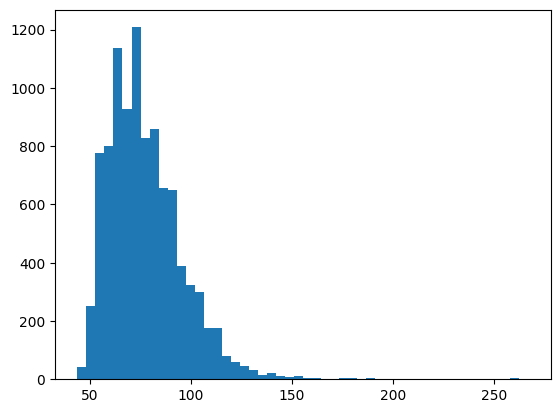

Max prompt length: 267
Max label length: 3


In [ ]:
# Plot a histogram to find max_length of tokens
utils.find_max_length(mnli_m_val, tokenizer=tokenizer, dataset_type='mnli')

In [ ]:
prompt_lengths, _ = utils.get_lengths(mnli_m_val, tokenizer, global_params['dataset_type'])
df = pd.DataFrame(prompt_lengths, columns=["length"])
tokens = 200 # Max length to check
n = (df["length"] > tokens).sum() # Number of prompts with # > tokens
percent = round(n/len(df)*100, 3)
print(f"Number of examples that have over {tokens} tokens and will be truncated: {n} out of {len(df)} examples or {percent}%")

Number of examples that have over 200 tokens and will be truncated: 10 out of 9815 examples or 0.102%


Since we have only 5 examples that goes over a length of 200, we are going to use 200 as the default for `max_length` and miss some information in order to offload computing.

In [ ]:
# Define dataset and create a dataloader.
dataset_test = utils.MyDataset(dataframe=mnli_m_val,
                               tokenizer=tokenizer,
                               dataset_type=global_params['dataset_type'],
                               prompt_max_length=200,
                               label_max_length=3)

batch_size = 5 # Change batch size according to GPU
dataloader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

In [ ]:
# Test
predictions, gold_labels, batch_probs = utils.test_run(model=model,
                                          dataloader=dataloader,
                                          tokenizer=tokenizer,
                                          dataset_type=global_params['dataset_type'])

for i, pair in enumerate(zip(predictions, gold_labels)):
    print(pair, batch_probs[i])

('neutral', 'neutral') tensor([0.1644, 0.4952, 0.3404], device='cuda:0')
('neutral', 'contradiction') tensor([0.1774, 0.4885, 0.3341], device='cuda:0')
('neutral', 'entailment') tensor([0.1734, 0.6194, 0.2073], device='cuda:0')
('neutral', 'contradiction') tensor([0.1691, 0.6129, 0.2180], device='cuda:0')
('neutral', 'contradiction') tensor([0.1444, 0.5720, 0.2836], device='cuda:0')


In [ ]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

Checkpoint found.


Evaluating:  76%|███████▋  | 1501/1963 [09:54<1:32:21, 11.99s/batch]

Checkpoint saved: 1501, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_Llama_3.2_3B_Instruct_full_zero_shot.pt


Evaluating:  79%|███████▉  | 1551/1963 [19:56<1:22:31, 12.02s/batch]

Checkpoint saved: 1551, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_Llama_3.2_3B_Instruct_full_zero_shot.pt


...

Checkpoint saved: 1901, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_Llama_3.2_3B_Instruct_full_zero_shot.pt


Evaluating:  99%|█████████▉| 1951/1963 [1:40:13<02:24, 12.06s/batch]

Checkpoint saved: 1951, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_Llama_3.2_3B_Instruct_full_zero_shot.pt


Evaluating: 100%|██████████| 1963/1963 [1:42:38<00:00,  3.14s/batch]

Checkpoint saved: 1963, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_Llama_3.2_3B_Instruct_full_zero_shot.pt


Checkpoint found.
Accuracy: 0.3469.
 F1 Score: 0.2509.
 Matthew's Correlation Coefficient: 0.0641.
 Cohen's Kappa Score: 0.0358.


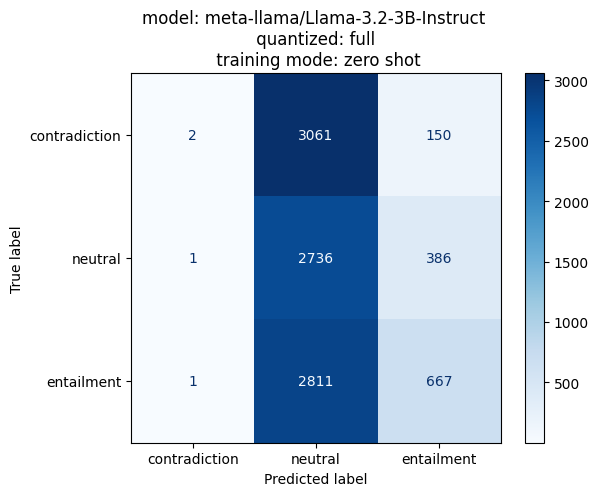

In [3]:
# Calculate metrics for batch_size = 25 and mnli_m
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)

# <center> Now to test the mismatched validation set separately. <center>

In [6]:
from google.colab import files
uploaded = files.upload()
mnli_mm_val = pd.read_csv('mnli_mm_val.csv')

mnli_mm_val["label"] = mnli_mm_val["label"].map({0: "entailment", 1: "neutral", 2: "contradiction"})

Saving mnli_mm_val.csv to mnli_mm_val.csv


In [ ]:
mnli_mm_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9832 entries, 0 to 9831
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   promptID                 9832 non-null   int64 
 1   pairID                   9832 non-null   object
 2   premise                  9832 non-null   object
 3   premise_binary_parse     9832 non-null   object
 4   premise_parse            9832 non-null   object
 5   hypothesis               9832 non-null   object
 6   hypothesis_binary_parse  9832 non-null   object
 7   hypothesis_parse         9832 non-null   object
 8   genre                    9832 non-null   object
 9   label                    9832 non-null   object
dtypes: int64(1), object(9)
memory usage: 768.3+ KB


In [ ]:
mnli_mm_val.head()

,promptID,pairID,premise,premise_binary_parse,premise_parse,hypothesis,hypothesis_binary_parse,hypothesis_parse,genre,label
0,75290,75290c,Your contribution helped make it possible for ...,( ( Your contribution ) ( ( helped ( make ( it...,(ROOT (S (NP (PRP$ Your) (NN contribution)) (V...,Your contributions were of no help with our st...,( ( Your contributions ) ( ( were ( of ( ( no ...,(ROOT (S (NP (PRP$ Your) (NNS contributions)) ...,letters,contradiction
1,133794,133794c,"The answer has nothing to do with their cause,...",( ( ( ( ( ( The answer ) ( ( ( ( has nothing )...,(ROOT (S (S (NP (DT The) (NN answer)) (VP (VBZ...,Dictionaries are indeed exercises in bi-unique...,( Dictionaries ( ( ( are indeed ) ( exercises ...,(ROOT (S (NP (NNS Dictionaries)) (VP (VBP are)...,verbatim,contradiction
2,3628,3628c,We serve a classic Tuscan meal that includes ...,( We ( ( serve ( ( a ( classic ( Tuscan meal )...,(ROOT (S (NP (PRP We)) (VP (VBP serve) (NP (NP...,We serve a meal of Florentine terrine.,( We ( ( serve ( ( a meal ) ( of ( Florentine ...,(ROOT (S (NP (PRP We)) (VP (VBP serve) (NP (NP...,verbatim,entailment
3,89411,89411c,"A few months ago, Carl Newton and I wrote a le...","( ( ( A ( few months ) ) ago ) ( , ( ( ( ( Car...",(ROOT (S (ADVP (NP (DT A) (JJ few) (NNS months...,Carl Newton and I have never had any other pre...,( ( ( ( Carl Newton ) and ) I ) ( ( ( have nev...,(ROOT (S (NP (NP (NNP Carl) (NNP Newton)) (CC ...,letters,contradiction
4,136158,136158e,"I was on this earth you know, I've lived on th...",( I ( ( was ( on ( ( this earth ) ( you ( know...,(ROOT (S (NP (PRP I)) (VP (VBD was) (PP (IN on...,I don't yet know the reason why I have lived o...,( I ( ( ( ( do n't ) yet ) ( ( know ( the reas...,(ROOT (S (NP (PRP I)) (VP (VBP do) (RB n't) (A...,facetoface,entailment


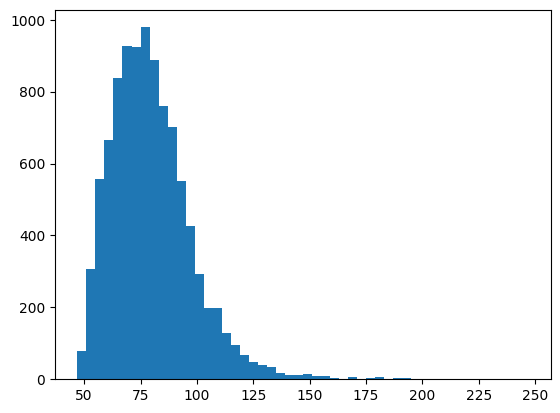

Max prompt length: 247
Max label length: 3


In [ ]:
# Plot a histogram to find max_length of tokens
utils.find_max_length(mnli_mm_val, tokenizer=tokenizer, dataset_type='mnli')

In [ ]:
prompt_lengths, _ = utils.get_lengths(mnli_mm_val, tokenizer, global_params['dataset_type'])
df = pd.DataFrame(prompt_lengths, columns=["length"])
tokens = 200 # Max length to check
n = (df["length"] > tokens).sum() # Number of prompts with # > tokens
percent = round(n/len(df)*100, 3)
print(f"Number of examples that have over {tokens} tokens and will be truncated: {n} out of {len(df)} examples or {percent}%")

Number of examples that have over 200 tokens and will be truncated: 12 out of 9832 examples or 0.122%


In [7]:
# Define dataset and create a dataloader.
dataset_test_mm = utils.MyDataset(dataframe=mnli_mm_val,
                               tokenizer=tokenizer,
                               dataset_type='mnli',
                               prompt_max_length=200,
                               label_max_length=3)

batch_size = 5 # Change batch size according to GPU
dataloader_mm = DataLoader(dataset_test_mm, batch_size=batch_size, shuffle=False)

In [8]:
from tqdm import tqdm

# Load checkpoint if it exists
predicted_labels, gold_labels, start_batch = utils.load_checkpoint(checkpoint_path=checkpoint_path)
labels = utils.get_labels(global_params['dataset_type'])

# Loop over the batches
with torch.no_grad():
    for i, batch in enumerate(tqdm(dataloader_mm, desc="Evaluating", unit="batch")):

        # Continue from last checkpoint
        if i < start_batch:
            continue

        input_ids_batch = batch["input_ids"].to(model.device) # Move to GPU
        attention_mask_batch = batch["attention_mask"].to(model.device) # Move to GPU
        gold_labels_batch = batch["labels"] # Keep to CPU

        batch_probs = utils.get_model_probs(batch_input_ids=input_ids_batch,
                                      batch_attention_mask=attention_mask_batch,
                                      dataset_type=global_params['dataset_type'],
                                      model=model,
                                      tokenizer=tokenizer)

        batch_pred_indices = torch.argmax(batch_probs, dim=1)
        batch_pred_labels = [labels[i] for i in batch_pred_indices]

        predicted_labels.extend(batch_pred_labels)
        gold_labels.extend(gold_labels_batch)

        # Save checkpoint
        if i % 50 == 0 or i == len(dataloader_mm) - 1:
            torch.save({"predicted_labels": predicted_labels,
                        "gold_labels": gold_labels,
                        "batch_no": i+1}, checkpoint_path)

            print(f"Checkpoint saved: {i+1}, {checkpoint_path}")

Checkpoint found.


Evaluating:  92%|█████████▏| 1801/1967 [09:45<32:12, 11.64s/batch]

Checkpoint saved: 1801, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Llama_3.2_3B_Instruct_full_zero_shot.pt


Evaluating:  94%|█████████▍| 1851/1967 [19:28<22:32, 11.66s/batch]

Checkpoint saved: 1851, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Llama_3.2_3B_Instruct_full_zero_shot.pt


...

Checkpoint saved: 1901, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Llama_3.2_3B_Instruct_full_zero_shot.pt


Evaluating:  99%|█████████▉| 1951/1967 [38:53<03:06, 11.65s/batch]

Checkpoint saved: 1951, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Llama_3.2_3B_Instruct_full_zero_shot.pt


Evaluating: 100%|██████████| 1967/1967 [41:54<00:00,  1.28s/batch]

Checkpoint saved: 1967, /content/drive/MyDrive/eval_checkpoints/checkpoint_mnli_mm_Llama_3.2_3B_Instruct_full_zero_shot.pt


Checkpoint found.
Accuracy: 0.3455.
 F1 Score: 0.2620.
 Matthew's Correlation Coefficient: 0.0487.
 Cohen's Kappa Score: 0.0316.


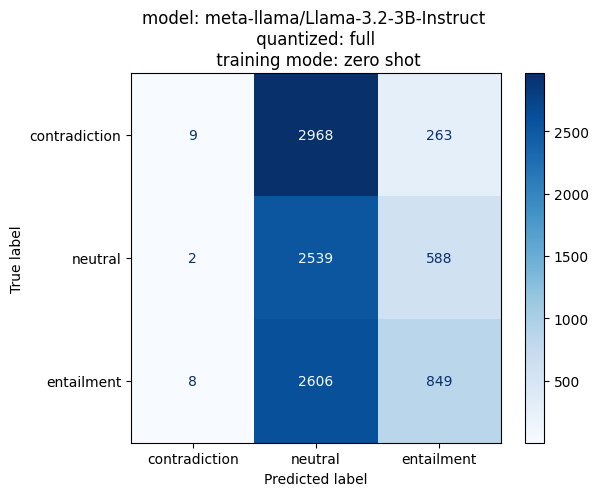

In [5]:
# Calculate metrics for batch_size = 25 and mnli_mm
predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)
utils.evaluate_metrics(predicted_labels=predicted_labels, gold_labels=gold_labels, params=global_params)